# Mall Shopper Profiling — Unsupervised Learning
## Practical Exam — Unsupervised Learning (Set B)

**Student:** Misari Dhorajiya  
**Project:** Mall Shopper Profiling  
**Domain:** Retail Analytics

### Objective
Build an end-to-end unsupervised learning solution to segment mall shoppers using demographic, income, and spending behaviour.

### Expected Output
- EDA and visual analysis
- Feature engineering and scaling
- K-Means with Elbow and Silhouette analysis
- Agglomerative clustering with dendrogram
- DBSCAN with k-NN distance analysis and grid tuning
- Multi-metric model comparison
- Cluster profiling and retail personas
- Stability analysis
- Saved model/scaler and reusable prediction function

# Task 1: Data Loading & Exploratory Data Analysis (EDA)

### Objective
Load the Mall Customer Segmentation dataset and understand its structure, distributions, customer characteristics, and relationships.

### Expected Output
Dataset inspection, clean columns, missing-value analysis, univariate plots, bivariate plots, correlation analysis, and initial clustering observations.

In [116]:
import os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
import joblib

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

DATA_PATH = "Mall_Customers.csv"
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError("Place Mall_Customers.csv in the same folder as this notebook.")

df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)
df.info()
print("\nFirst 10 rows:")
display(df.head(10))
print("\nOriginal columns:")
print(df.columns.tolist())
print("\nMissing values:")
display(df.isnull().sum().to_frame("Missing Values"))
print("\nGender counts:")
print(df["Gender"].value_counts())

Dataset Shape: (200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

First 10 rows:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72



Original columns:
['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Missing values:


,Missing Values
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0



Gender counts:
Gender
Female    112
Male       88
Name: count, dtype: int64


## Task 1.1: Load & Inspect the Dataset

### Objective
Load the Mall Customer Segmentation dataset, inspect its structure, rename the columns, check missing values, and understand the gender distribution.

### Expected Output
Dataset shape, information, first 10 rows, clean column names, missing-value summary, and male/female customer counts.

In [117]:
df.rename(columns={
    "Genre": "Gender",
    "Annual Income (k$)": "AnnualIncome",
    "Spending Score (1-100)": "SpendingScore"
}, inplace=True)

print(df.columns.tolist())
display(df.head())

['CustomerID', 'Gender', 'Age', 'AnnualIncome', 'SpendingScore']


,CustomerID,Gender,Age,AnnualIncome,SpendingScore
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Task 1.2: Univariate Analysis

**Objective:** Analyze Age, Annual Income, Spending Score, and Gender individually.

**Expected Output:** Three histograms, three boxplots, one Gender countplot, and distribution observations.

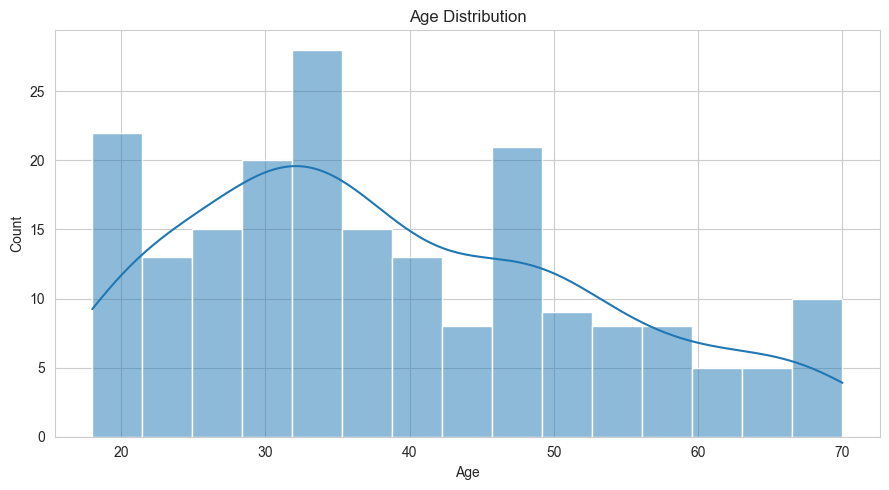

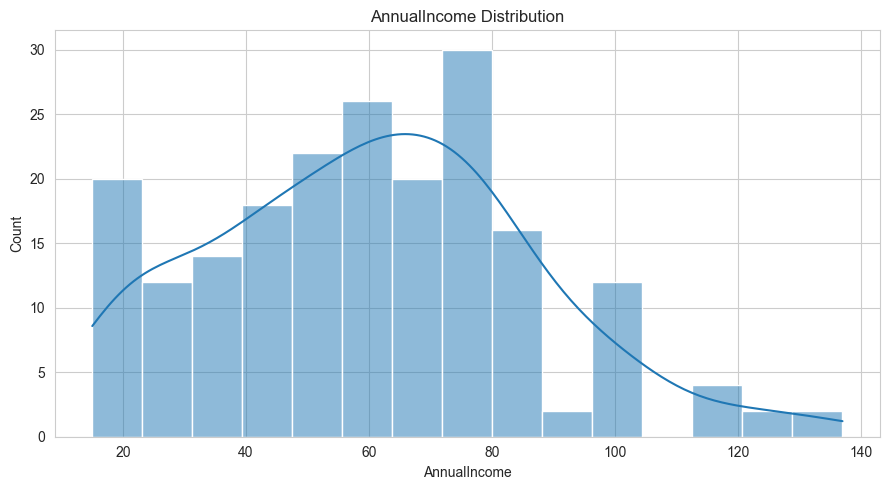

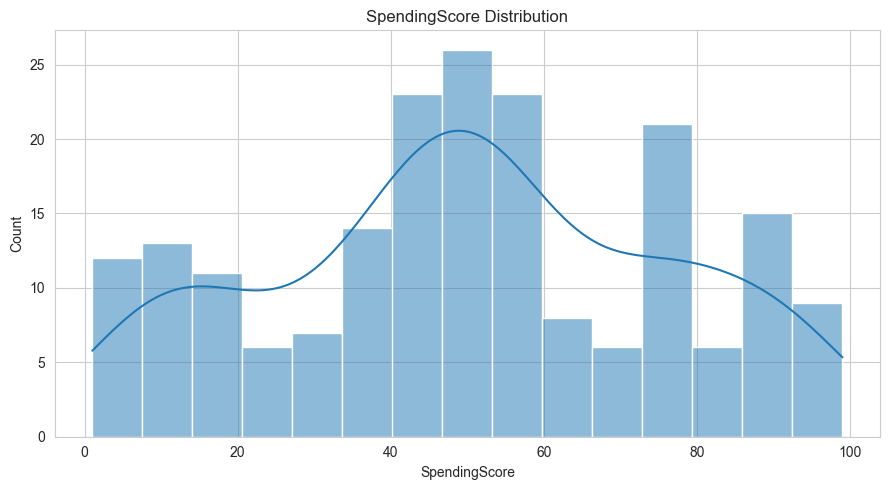

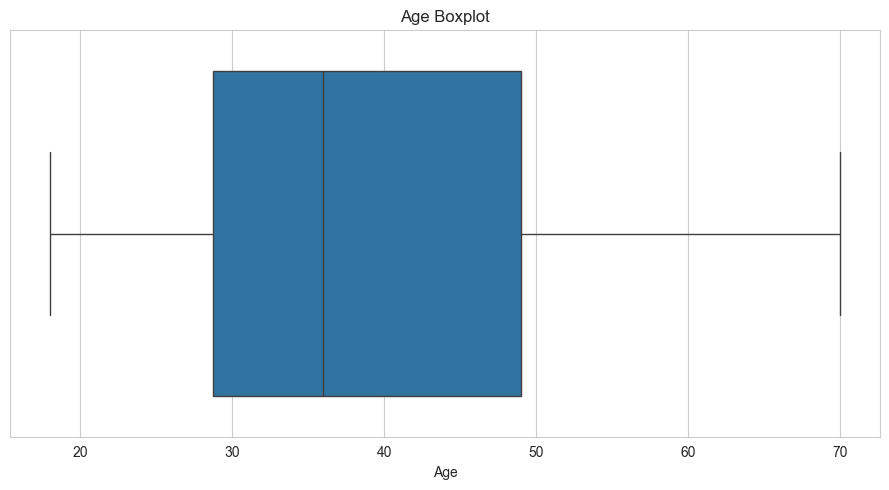

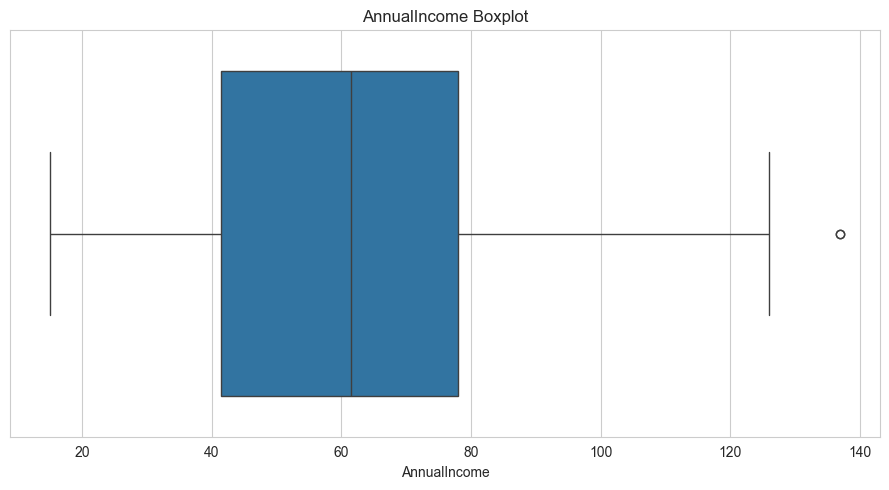

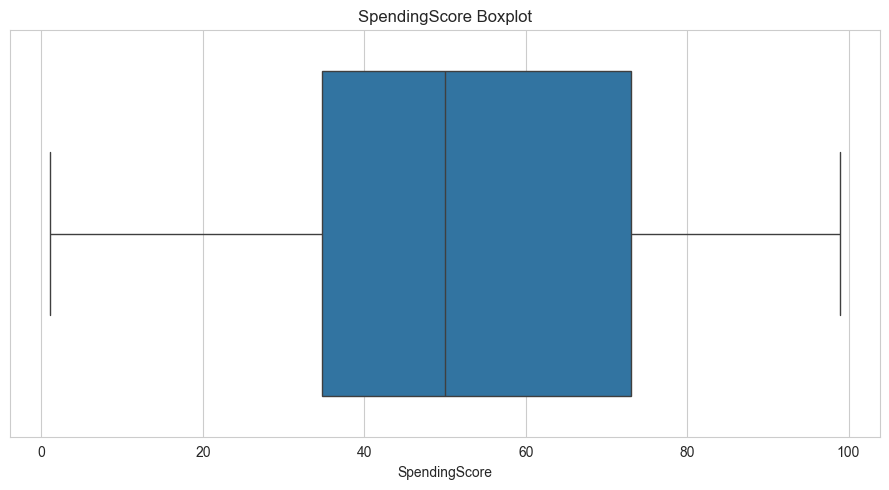

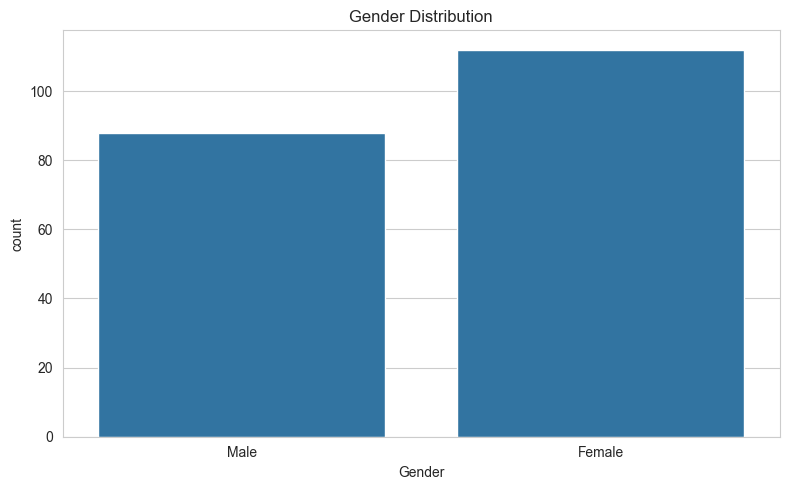

Gender percentage:


Gender
Female    56.0
Male      44.0
Name: proportion, dtype: float64

In [118]:
features = ["Age", "AnnualIncome", "SpendingScore"]

for i, feature in enumerate(features, 1):
    plt.figure(figsize=(9, 5))
    sns.histplot(df[feature], bins=15, kde=True)
    plt.title(f"{feature} Distribution")
    plt.tight_layout()
    plt.savefig(f"0{i}_{feature}_Distribution.png", dpi=300, bbox_inches="tight")
    plt.show()

for i, feature in enumerate(features, 4):
    plt.figure(figsize=(9, 5))
    sns.boxplot(x=df[feature])
    plt.title(f"{feature} Boxplot")
    plt.tight_layout()
    plt.savefig(f"0{i}_{feature}_Boxplot.png", dpi=300, bbox_inches="tight")
    plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Gender")
plt.title("Gender Distribution")
plt.tight_layout()
plt.savefig("07_Gender_Countplot.png", dpi=300, bbox_inches="tight")
plt.show()

print("Gender percentage:")
display((df["Gender"].value_counts(normalize=True) * 100).round(2))

## Task 1.3: Bivariate Analysis

**Objective:** Analyze relationships and identify possible natural customer groups before clustering.

**Expected Output:** Income vs Spending, Age vs Spending by Gender, Age vs Income by Gender, correlation matrix, and heatmap.

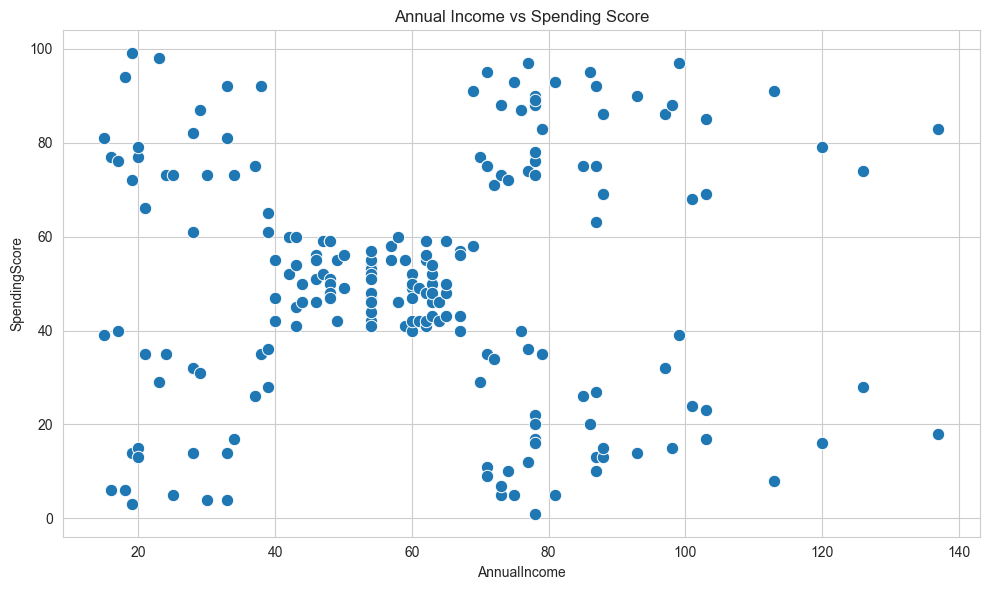

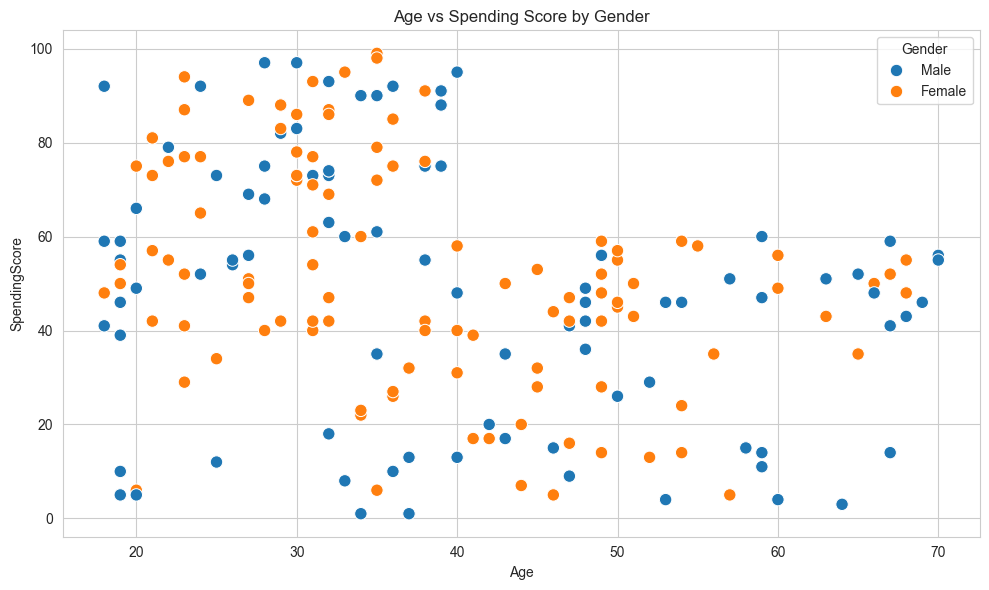

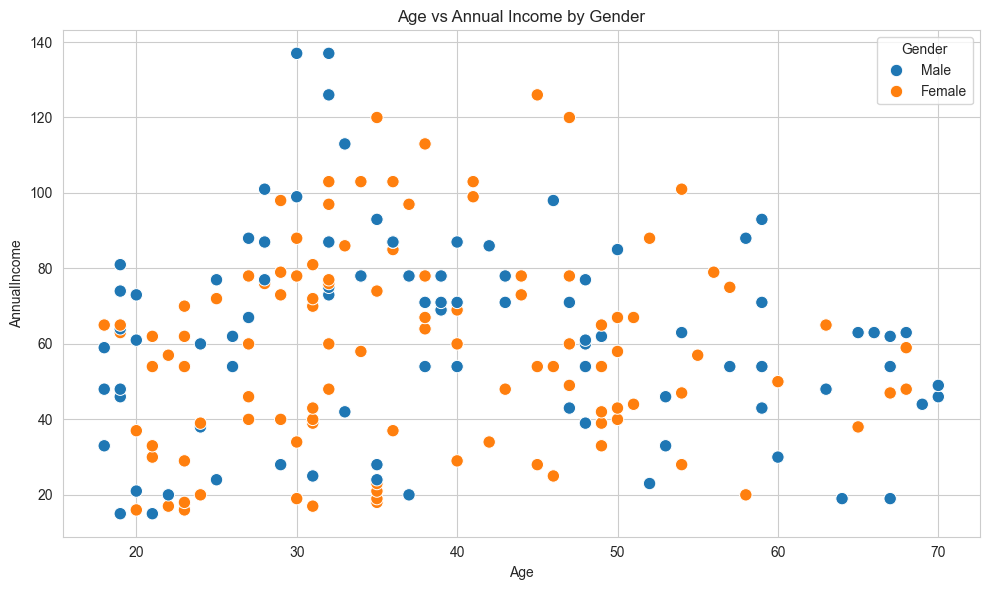

,CustomerID,Age,AnnualIncome,SpendingScore
CustomerID,1.000,-0.027,0.978,0.014
Age,-0.027,1.000,-0.012,-0.327
AnnualIncome,0.978,-0.012,1.000,0.010
SpendingScore,0.014,-0.327,0.010,1.000


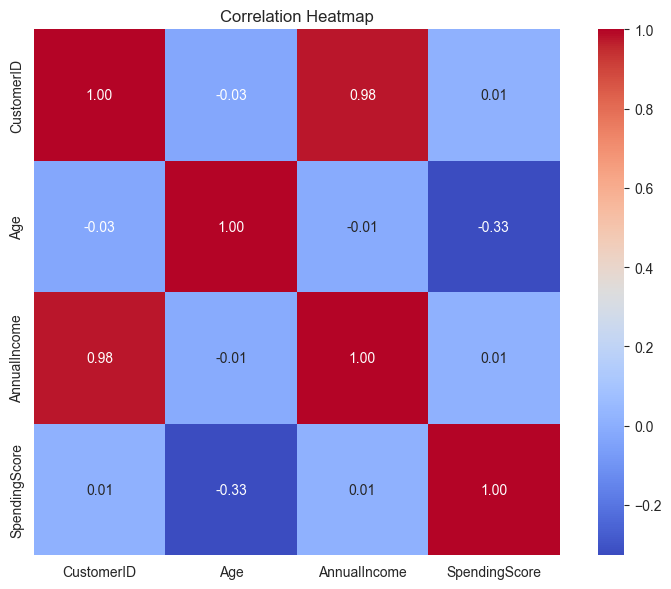

In [119]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="AnnualIncome", y="SpendingScore", s=80)
plt.title("Annual Income vs Spending Score")
plt.tight_layout()
plt.savefig("08_AnnualIncome_vs_SpendingScore.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Age", y="SpendingScore", hue="Gender", s=80)
plt.title("Age vs Spending Score by Gender")
plt.tight_layout()
plt.savefig("09_Age_vs_SpendingScore_by_Gender.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Age", y="AnnualIncome", hue="Gender", s=80)
plt.title("Age vs Annual Income by Gender")
plt.tight_layout()
plt.savefig("10_Age_vs_AnnualIncome_by_Gender.png", dpi=300, bbox_inches="tight")
plt.show()

corr = df[["CustomerID", "Age", "AnnualIncome", "SpendingScore"]].corr()
display(corr.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("11_Correlation_Heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

### Task 1.3.6: Initial Clustering Observation

The **Annual Income vs Spending Score** plot is the core clustering canvas. Inspect it before applying any algorithm and describe the naturally visible shopper groups. These visual groups will later be compared with algorithm-generated clusters.

## Task 1.4: Gender-Wise Analysis

**Objective:** Compare Male and Female customers using mean Age, Annual Income, and Spending Score.

**Expected Output:** Mean table, grouped bar chart, and 2–3 sentence interpretation.

,Age,AnnualIncome,SpendingScore
Gender,,,
Female,38.10,59.25,51.53
Male,39.81,62.23,48.51


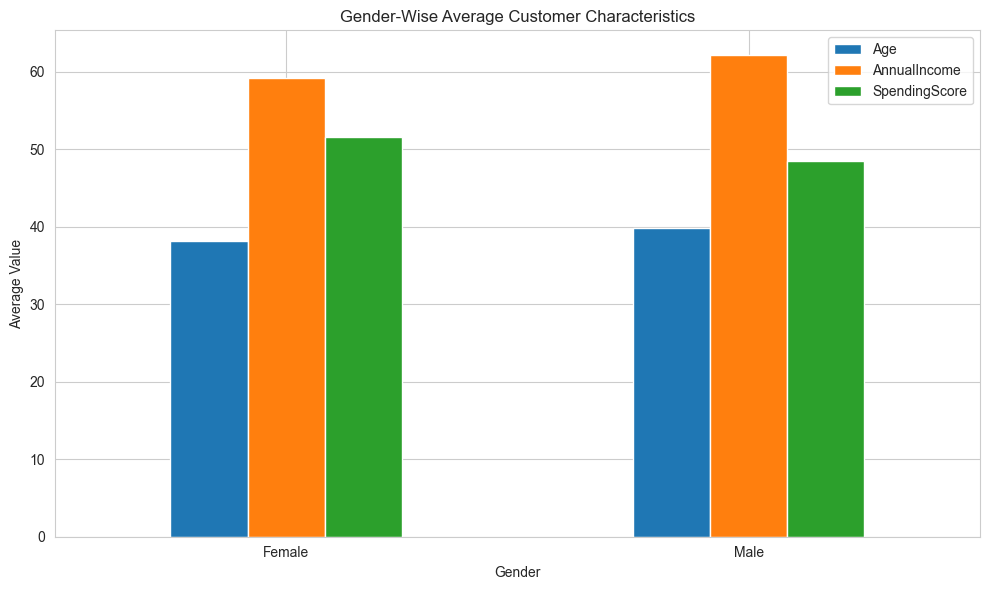

In [120]:
gender_means = df.groupby("Gender")[["Age", "AnnualIncome", "SpendingScore"]].mean().round(2)
display(gender_means)

gender_means.plot(kind="bar", figsize=(10, 6))
plt.title("Gender-Wise Average Customer Characteristics")
plt.xlabel("Gender")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("12_GenderWise_Mean_Comparison.png", dpi=300, bbox_inches="tight")
plt.show()

### Gender-Wise Observation

Compare the displayed means and write 2–3 sentences covering:
- which gender has higher average income,
- which has higher average spending score,
- whether average age differs substantially.

The income/spending scatter will be used as the primary segmentation space in the next tasks.

# Task 2: Feature Engineering & Preprocessing

### Objective
Encode categorical data, create meaningful customer groups, prepare clustering feature matrices, and standardize the features.

### Expected Output
Gender encoding, IncomeGroup, AgeGroup, SpendingCategory, 2D features, multivariate features, and scaled features.

## Task 2.1: Label Encoding Gender

**Objective:** Encode Female as 0 and Male as 1 while keeping the original Gender column.

**Expected Output:** New `Gender_enc` column.

In [121]:
df["Gender_enc"] = df["Gender"].map({"Female": 0, "Male": 1})
display(df[["Gender", "Gender_enc"]].head(10))

,Gender,Gender_enc
0,Male,1
1,Male,1
2,Female,0
3,Female,0
4,Female,0
5,Female,0
6,Female,0
7,Female,0
8,Male,1
9,Female,0


## Task 2.2: Feature Engineering

**Objective:** Create income, age, and spending categories.

**Expected Output:**
- IncomeGroup: Low / Medium / High using quantiles
- AgeGroup: Young / Adult / Middle-Aged / Senior
- SpendingCategory: Low / Medium / High

In [122]:
df["IncomeGroup"] = pd.qcut(df["AnnualIncome"], q=3, labels=["Low", "Medium", "High"])

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[17, 25, 40, 55, np.inf],
    labels=["Young", "Adult", "Middle-Aged", "Senior"]
)

df["SpendingCategory"] = pd.cut(
    df["SpendingScore"],
    bins=[0, 33, 66, 100],
    labels=["Low", "Medium", "High"]
)

for col in ["IncomeGroup", "AgeGroup", "SpendingCategory"]:
    print(f"\n{col}:")
    print(df[col].value_counts())


IncomeGroup:
IncomeGroup
Low       70
High      66
Medium    64
Name: count, dtype: int64

AgeGroup:
AgeGroup
Adult          84
Middle-Aged    49
Young          38
Senior         29
Name: count, dtype: int64

SpendingCategory:
SpendingCategory
Medium    94
High      57
Low       49
Name: count, dtype: int64


## Task 2.3: Create Feature Matrices

**Objective:** Create two clustering experiments.

**Experiment A — 2D:** `AnnualIncome`, `SpendingScore`

**Experiment B — Multivariate:** `Age`, `AnnualIncome`, `SpendingScore`, `Gender_enc`

**Note:** The exam brief calls Experiment B “5D” but lists four actual features. This notebook follows the listed features.

In [123]:
X_2d = df[["AnnualIncome", "SpendingScore"]].copy()
X_5d = df[["Age", "AnnualIncome", "SpendingScore", "Gender_enc"]].copy()

print("X_2d Shape:", X_2d.shape)
print("X_5d Shape:", X_5d.shape)
display(X_2d.head())
display(X_5d.head())

X_2d Shape: (200, 2)
X_5d Shape: (200, 4)


,AnnualIncome,SpendingScore
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


,Age,AnnualIncome,SpendingScore,Gender_enc
0,19,15,39,1
1,21,15,81,1
2,20,16,6,0
3,23,16,77,0
4,31,17,40,0


## Task 2.4: Feature Scaling

**Objective:** Standardize features so distance-based algorithms are not dominated by variables with larger scales.

**Expected Output:** Scaled matrices with mean approximately 0 and standard deviation approximately 1.

In [124]:
scaler_2d = StandardScaler()
scaler_5d = StandardScaler()

X_2d_scaled = scaler_2d.fit_transform(X_2d)
X_5d_scaled = scaler_5d.fit_transform(X_5d)

print("X_2d_scaled shape:", X_2d_scaled.shape)
print("X_5d_scaled shape:", X_5d_scaled.shape)

display(pd.DataFrame(X_2d_scaled, columns=X_2d.columns).agg(["mean", "std"]).round(4))
display(pd.DataFrame(X_5d_scaled, columns=X_5d.columns).agg(["mean", "std"]).round(4))

X_2d_scaled shape: (200, 2)
X_5d_scaled shape: (200, 4)


,AnnualIncome,SpendingScore
mean,-0.0000,-0.0000
std,1.0025,1.0025


,Age,AnnualIncome,SpendingScore,Gender_enc
mean,-0.0000,-0.0000,-0.0000,0.0000
std,1.0025,1.0025,1.0025,1.0025


# Task 3: K-Means Clustering

K-Means is an unsupervised clustering algorithm that divides customers into groups based on similarity.

In this step, K-Means clustering will be performed using:
- Elbow Method
- Silhouette Score
- 2D feature set
- 5D feature set
- Cluster visualisation
- Cluster profiling
- Retail persona interpretation

## 3.1 Elbow Method — Find Optimal k

### Objective

Find the optimal number of clusters for K-Means clustering using the Elbow Method and Silhouette Score.

### Process

- Test k values from 2 to 10.
- Calculate K-Means inertia for each k.
- Plot the Elbow Curve.
- Calculate Silhouette Score for each k.
- Compare both results and select the optimal k.

In [125]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 11)

inertias = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        random_state=42
    )
    
    kmeans.fit(X_2d_scaled)
    inertias.append(kmeans.inertia_)

print("Inertia values:")
for k, inertia in zip(k_values, inertias):
    print(f"k = {k}: Inertia = {inertia:.2f}")

Inertia values:
k = 2: Inertia = 269.69
k = 3: Inertia = 157.70
k = 4: Inertia = 108.92
k = 5: Inertia = 65.57
k = 6: Inertia = 55.06
k = 7: Inertia = 44.86
k = 8: Inertia = 37.23
k = 9: Inertia = 32.39
k = 10: Inertia = 29.98


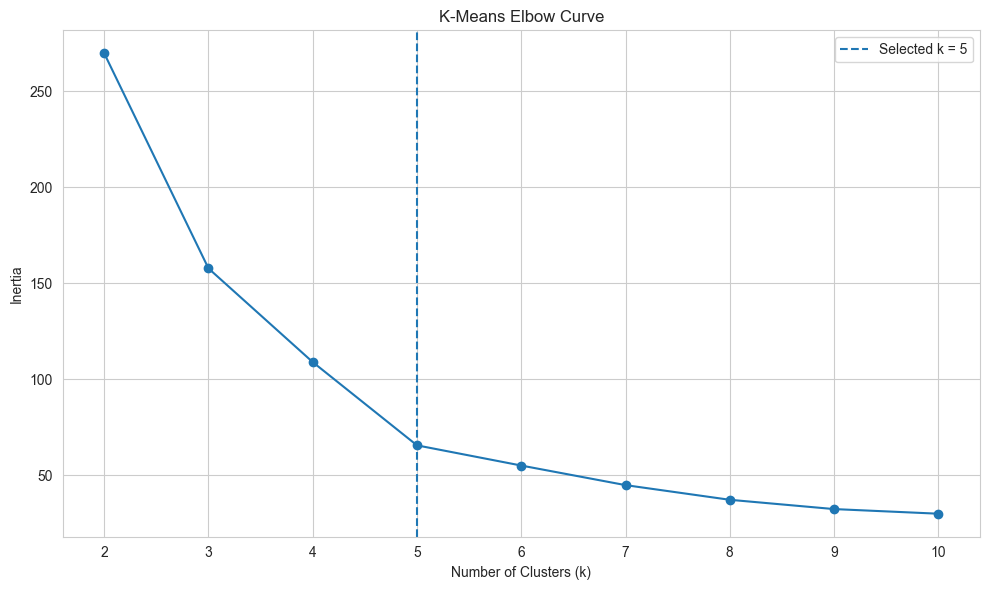

In [126]:
plt.figure(figsize=(10, 6))

plt.plot(
    k_results["k"],
    k_results["Inertia"],
    marker="o"
)

plt.axvline(
    x=5,
    linestyle="--",
    label="Selected k = 5"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Curve")
plt.legend()
plt.tight_layout()

plt.savefig(
    "13_KMeans_Elbow_Curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

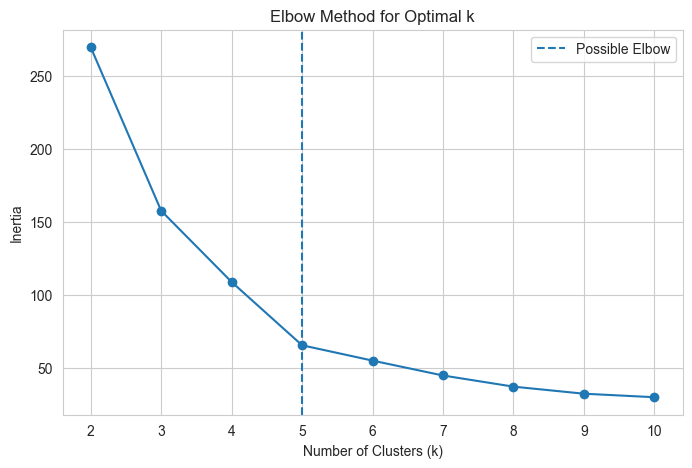

In [127]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertias,
    marker="o"
)

plt.axvline(
    x=5,
    linestyle="--",
    label="Possible Elbow"
)

plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.legend()
plt.show()

In [128]:
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        random_state=42
    )
    
    cluster_labels = kmeans.fit_predict(X_2d_scaled)
    
    score = silhouette_score(
        X_2d_scaled,
        cluster_labels
    )
    
    silhouette_scores.append(score)

print("Silhouette Scores:")

for k, score in zip(k_values, silhouette_scores):
    print(f"k = {k}: Silhouette Score = {score:.4f}")

Silhouette Scores:
k = 2: Silhouette Score = 0.3213
k = 3: Silhouette Score = 0.4666
k = 4: Silhouette Score = 0.4939
k = 5: Silhouette Score = 0.5547
k = 6: Silhouette Score = 0.5399
k = 7: Silhouette Score = 0.5281
k = 8: Silhouette Score = 0.4552
k = 9: Silhouette Score = 0.4571
k = 10: Silhouette Score = 0.4432


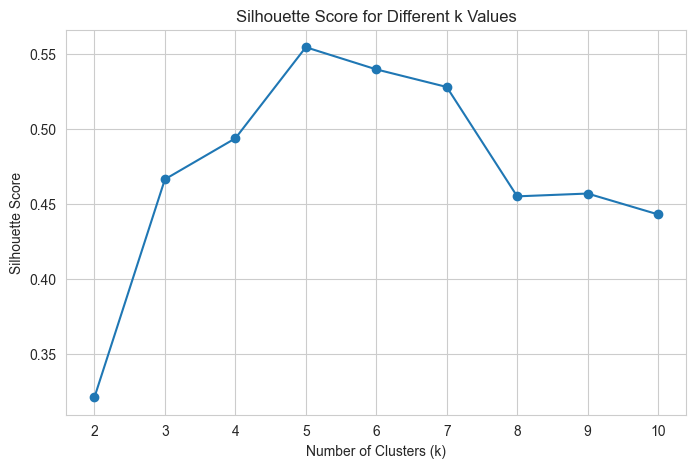

In [129]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score for Different k Values")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values))
plt.grid(True)

plt.show()

In [130]:
best_k_by_silhouette = k_values[
    silhouette_scores.index(max(silhouette_scores))
]

best_silhouette = max(silhouette_scores)

print("Best k according to Silhouette Score:", best_k_by_silhouette)
print("Best Silhouette Score:", round(best_silhouette, 4))

Best k according to Silhouette Score: 5
Best Silhouette Score: 0.5547


In [131]:
k_results = pd.DataFrame({
    "k": list(k_values),
    "Inertia": inertias,
    "Silhouette_Score": silhouette_scores
})

display(k_results)

,k,Inertia,Silhouette_Score
0,2,269.691012,0.321271
1,3,157.704008,0.466585
2,4,108.921317,0.493907
3,5,65.568408,0.554657
4,6,55.057348,0.539880
5,7,44.864756,0.528149
6,8,37.228188,0.455215
7,9,32.392268,0.457085
8,10,29.981898,0.443171


## Task 3.2: Final K-Means Models

**Objective:** Train 2D K-Means and a multivariate K-Means model and compare their silhouette scores.

In [132]:
k_optimal = best_k_by_silhouette

print("Selected Optimal k:", k_optimal)

Selected Optimal k: 5


In [133]:
kmeans_2d = KMeans(
    n_clusters=k_optimal, init="k-means++", n_init=20,
    max_iter=500, random_state=42
)
df["KMeans_Cluster"] = kmeans_2d.fit_predict(X_2d_scaled)

kmeans_5d = KMeans(
    n_clusters=k_optimal, init="k-means++", n_init=20,
    max_iter=500, random_state=42
)
df["KMeans_5D_Cluster"] = kmeans_5d.fit_predict(X_5d_scaled)

print("2D silhouette:", round(silhouette_score(X_2d_scaled, df["KMeans_Cluster"]), 4))
print("Multivariate silhouette:", round(silhouette_score(X_5d_scaled, df["KMeans_5D_Cluster"]), 4))

2D silhouette: 0.5547
Multivariate silhouette: 0.3144


In [134]:
display(
    df[
        [
            "CustomerID",
            "Gender",
            "Age",
            "AnnualIncome",
            "SpendingScore",
            "KMeans_Cluster",
            "KMeans_5D_Cluster"
        ]
    ].head(10)
)

,CustomerID,Gender,Age,AnnualIncome,SpendingScore,KMeans_Cluster,KMeans_5D_Cluster
0,1,Male,19,15,39,4,1
1,2,Male,21,15,81,2,1
2,3,Female,20,16,6,4,0
3,4,Female,23,16,77,2,4
4,5,Female,31,17,40,4,0
5,6,Female,22,17,76,2,4
6,7,Female,35,18,6,4,0
7,8,Female,23,18,94,2,4
8,9,Male,64,19,3,4,2
9,10,Female,30,19,72,2,4


## Task 3.3: K-Means Visualization

**Expected Output:** Income/spending clusters with centroids, Age/Spending clusters, and PCA projection of the multivariate experiment.

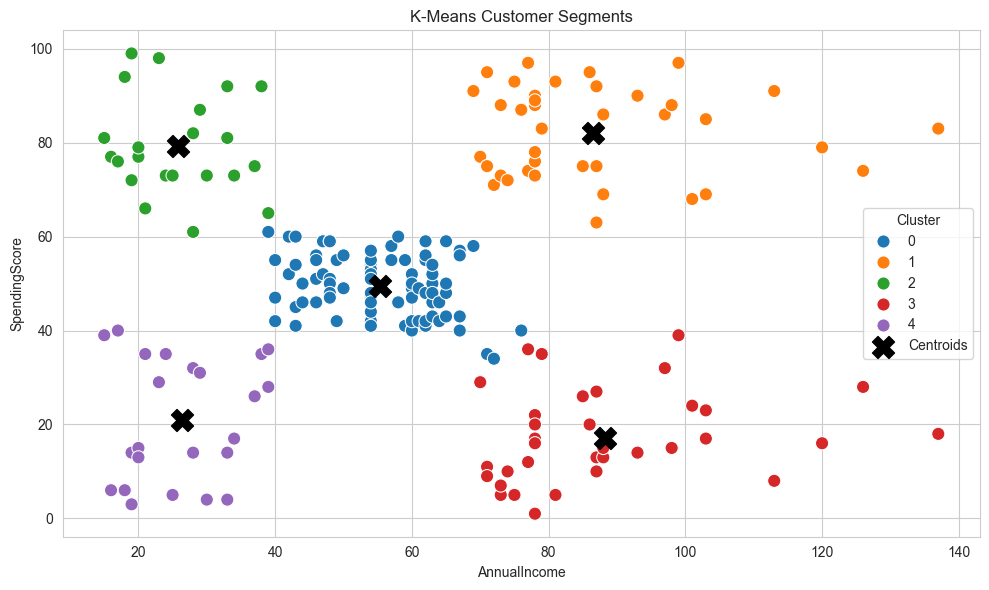

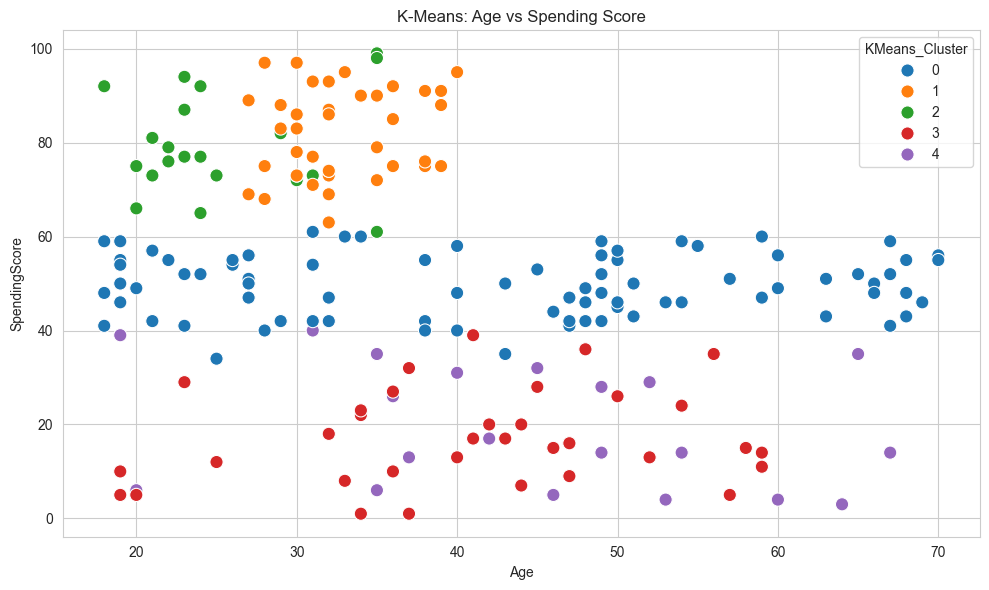

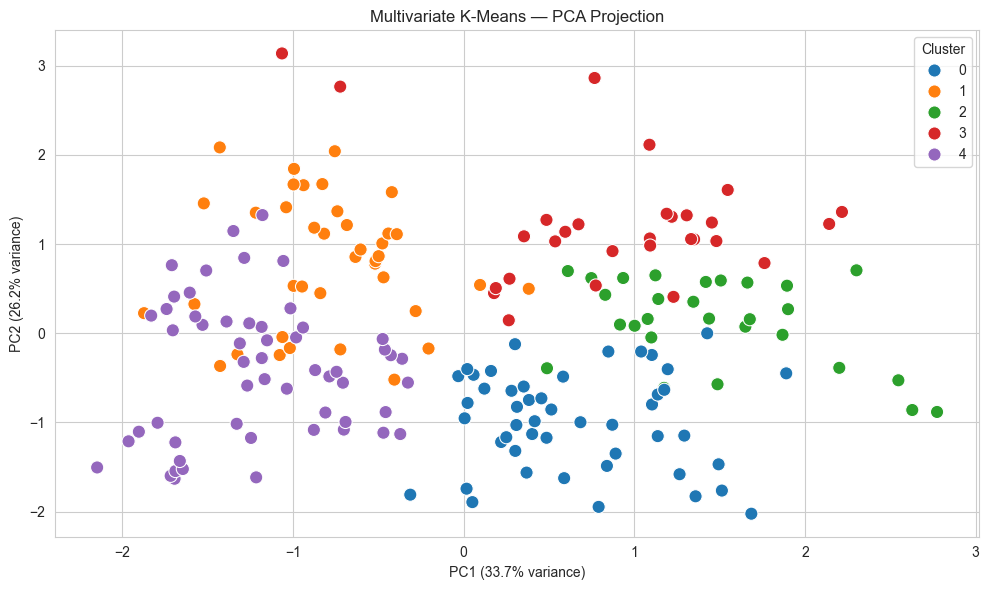

PCA explained variance: [0.3369 0.2623]


In [135]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="AnnualIncome", y="SpendingScore",
                hue="KMeans_Cluster", palette="tab10", s=90)
centroids = scaler_2d.inverse_transform(kmeans_2d.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], marker="X", s=250, c="black", label="Centroids")
plt.title("K-Means Customer Segments")
plt.legend(title="Cluster")
plt.tight_layout()
plt.savefig("15_KMeans_Clusters_with_Centroids.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Age", y="SpendingScore",
                hue="KMeans_Cluster", palette="tab10", s=90)
plt.title("K-Means: Age vs Spending Score")
plt.tight_layout()
plt.savefig("16_KMeans_Age_vs_Spending.png", dpi=300, bbox_inches="tight")
plt.show()

pca = PCA(n_components=2)
pca_values = pca.fit_transform(X_5d_scaled)
pca_df = pd.DataFrame({"PC1": pca_values[:, 0], "PC2": pca_values[:, 1],
                       "Cluster": df["KMeans_5D_Cluster"]})

plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2",
                hue="Cluster", palette="tab10", s=90)
plt.title("Multivariate K-Means — PCA Projection")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.tight_layout()
plt.savefig("17_KMeans_Multivariate_PCA.png", dpi=300, bbox_inches="tight")
plt.show()

print("PCA explained variance:", pca.explained_variance_ratio_.round(4))

## Task 3.4: K-Means Cluster Profiling

**Objective:** Profile each cluster using customer count, age, income, spending score, and gender composition.

In [136]:
cluster_profile = df.groupby("KMeans_Cluster").agg(
    Customers=("CustomerID", "count"),
    Avg_Age=("Age", "mean"),
    Avg_AnnualIncome=("AnnualIncome", "mean"),
    Avg_SpendingScore=("SpendingScore", "mean")
).round(2).sort_values("Avg_SpendingScore", ascending=False)

display(cluster_profile)

gender_cluster_pct = pd.crosstab(
    df["KMeans_Cluster"], df["Gender"], normalize="index"
).mul(100).round(2)

display(gender_cluster_pct)

,Customers,Avg_Age,Avg_AnnualIncome,Avg_SpendingScore
KMeans_Cluster,,,,
1,39,32.69,86.54,82.13
2,22,25.27,25.73,79.36
0,81,42.72,55.30,49.52
4,23,45.22,26.30,20.91
3,35,41.11,88.20,17.11


Gender,Female,Male
KMeans_Cluster,,
0,59.26,40.74
1,53.85,46.15
2,59.09,40.91
3,45.71,54.29
4,60.87,39.13


# Task 4: Agglomerative Clustering

### Objective
Use Ward dendrogram analysis, compare Ward/Complete/Average linkage, profile clusters, and compare the result with K-Means.

## Task 4.1: Dendrogram Analysis
**Objective:** Visualize the hierarchical structure and inspect a reasonable cut.

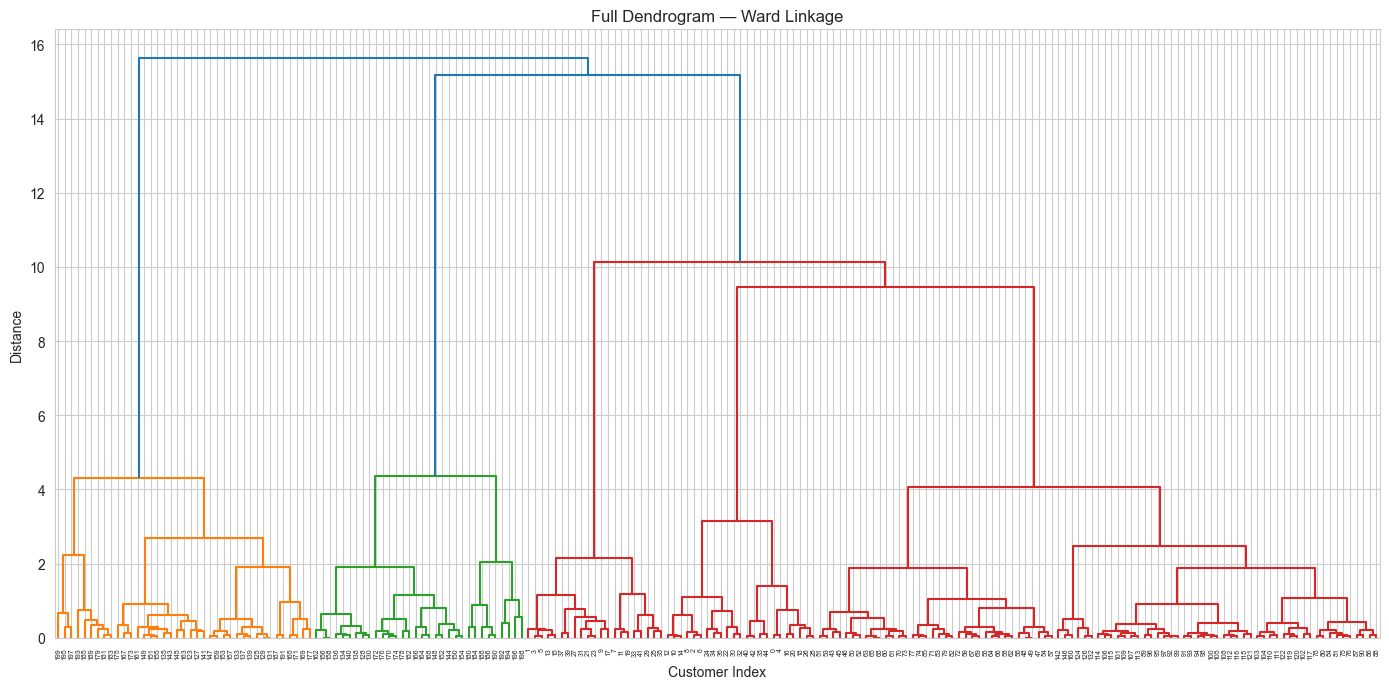

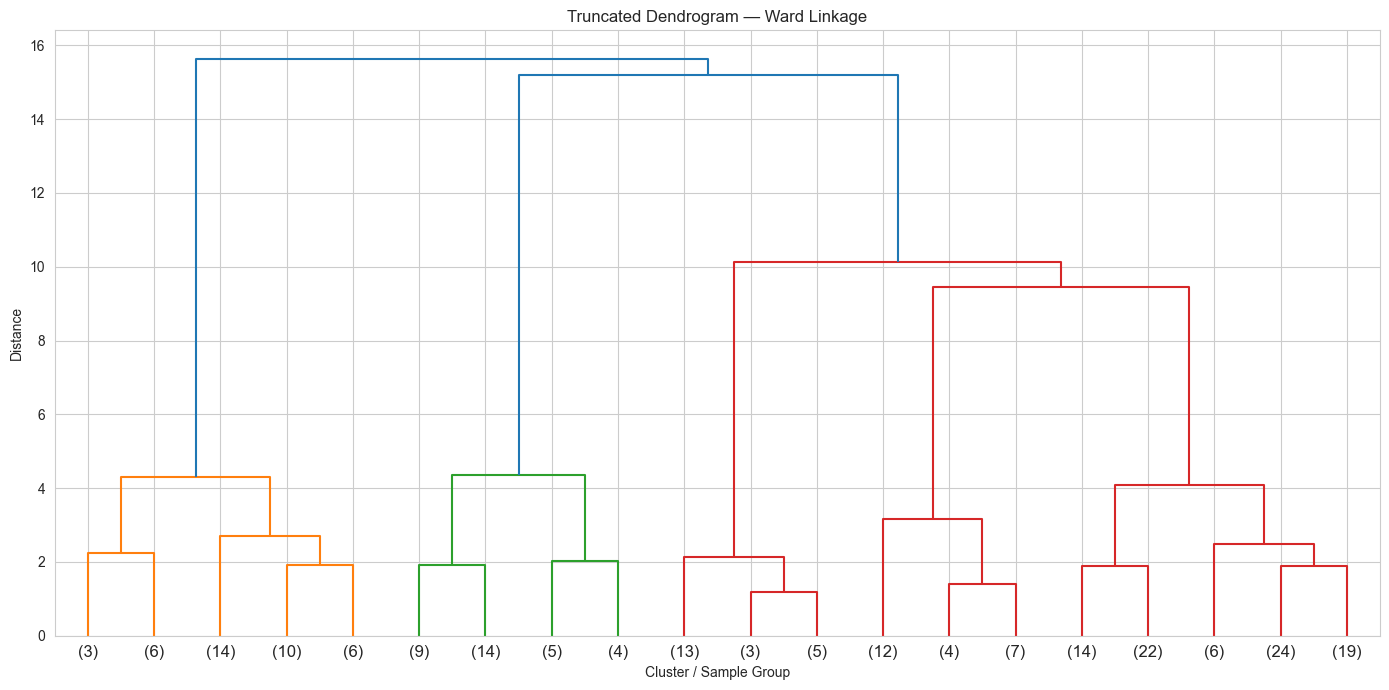

In [137]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

Z = linkage(
    X_2d_scaled,
    method="ward"
)

# Full dendrogram
plt.figure(figsize=(14, 7))

dendrogram(Z)

plt.title("Full Dendrogram — Ward Linkage")
plt.xlabel("Customer Index")
plt.ylabel("Distance")
plt.tight_layout()

plt.savefig(
    "18_Agglomerative_Full_Dendrogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Truncated dendrogram
plt.figure(figsize=(14, 7))

dendrogram(
    Z,
    truncate_mode="lastp",
    p=20,
    show_leaf_counts=True
)

plt.title("Truncated Dendrogram — Ward Linkage")
plt.xlabel("Cluster / Sample Group")
plt.ylabel("Distance")
plt.tight_layout()

plt.savefig(
    "19_Agglomerative_Truncated_Dendrogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Dendrogram cut threshold: 6.9039
Number of clusters from dendrogram: 5


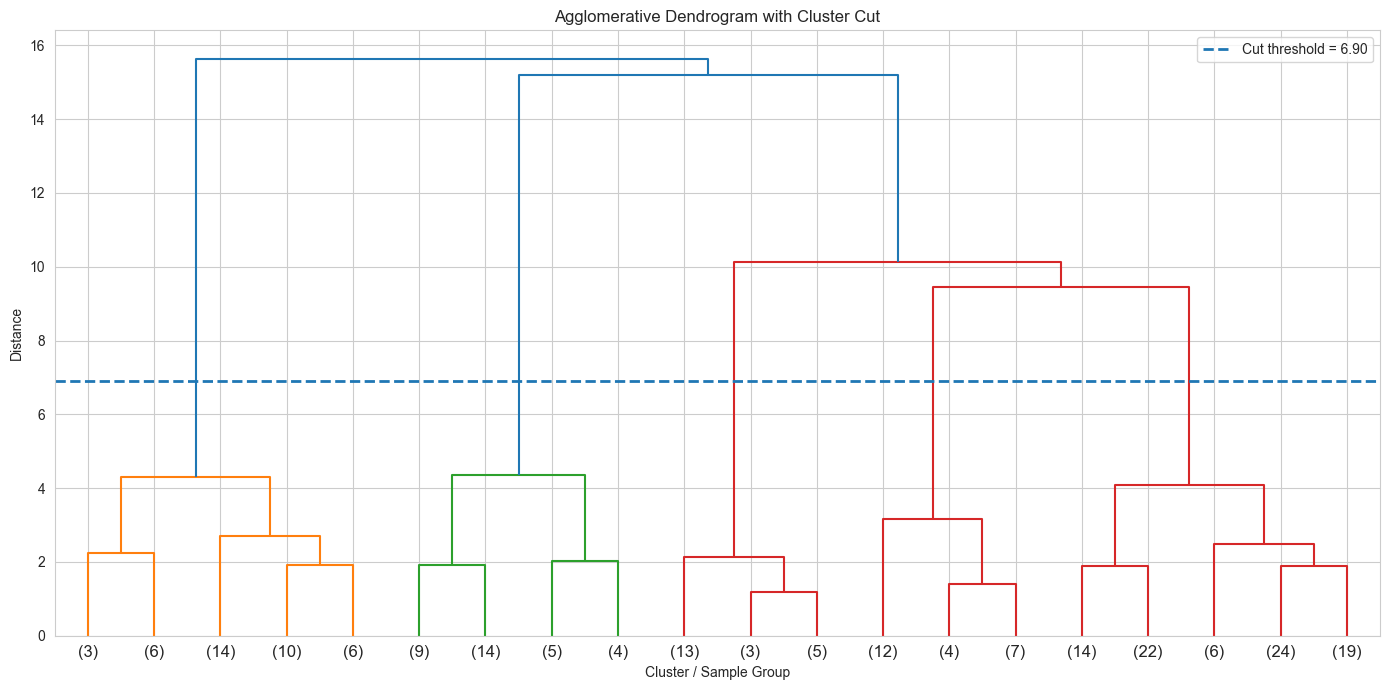

In [138]:
# Find a large gap between consecutive merge distances
distances = Z[:, 2]

sorted_distances = np.sort(distances)

gaps = np.diff(sorted_distances)

largest_gap_index = np.argmax(gaps)

cut_threshold = (
    sorted_distances[largest_gap_index]
    + sorted_distances[largest_gap_index + 1]
) / 2

# Determine number of clusters
dendrogram_labels = fcluster(
    Z,
    t=cut_threshold,
    criterion="distance"
)

n_chosen = len(np.unique(dendrogram_labels))

print("Dendrogram cut threshold:", round(cut_threshold, 4))
print("Number of clusters from dendrogram:", n_chosen)

plt.figure(figsize=(14, 7))

dendrogram(
    Z,
    truncate_mode="lastp",
    p=20,
    show_leaf_counts=True
)

plt.axhline(
    y=cut_threshold,
    linestyle="--",
    linewidth=2,
    label=f"Cut threshold = {cut_threshold:.2f}"
)

plt.title("Agglomerative Dendrogram with Cluster Cut")
plt.xlabel("Cluster / Sample Group")
plt.ylabel("Distance")
plt.legend()

plt.tight_layout()

plt.savefig(
    "20_Agglomerative_Dendrogram_Cut.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Dendrogram Observation

The horizontal dashed line represents the selected distance threshold. The number of clusters formed below this threshold is reported from the hierarchical tree.

The cut was selected around a large separation in merge distances, providing a natural division of the customer observations into distinct groups.

## Task 4.2: Compare Linkage Methods

**Objective:** Compare Ward, Complete, and Average linkage using silhouette score.

In [139]:
linkage_rows = []

for name in ["ward", "complete", "average"]:
    model = AgglomerativeClustering(n_clusters=n_chosen, linkage=name)
    labels = model.fit_predict(X_2d_scaled)
    linkage_rows.append({
        "Linkage": name,
        "Silhouette": silhouette_score(X_2d_scaled, labels)
    })

linkage_df = pd.DataFrame(linkage_rows).sort_values("Silhouette", ascending=False)
display(linkage_df.round(4))

best_linkage = linkage_df.iloc[0]["Linkage"]

agg_model = AgglomerativeClustering(n_clusters=n_chosen, linkage=best_linkage)
df["Agg_Cluster"] = agg_model.fit_predict(X_2d_scaled)

print("Selected linkage:", best_linkage)
print("Final silhouette:", round(silhouette_score(X_2d_scaled, df["Agg_Cluster"]), 4))

,Linkage,Silhouette
0,ward,0.5538
1,complete,0.5531
2,average,0.4794


Selected linkage: ward
Final silhouette: 0.5538


## Task 4.3: Visualization and Profiling

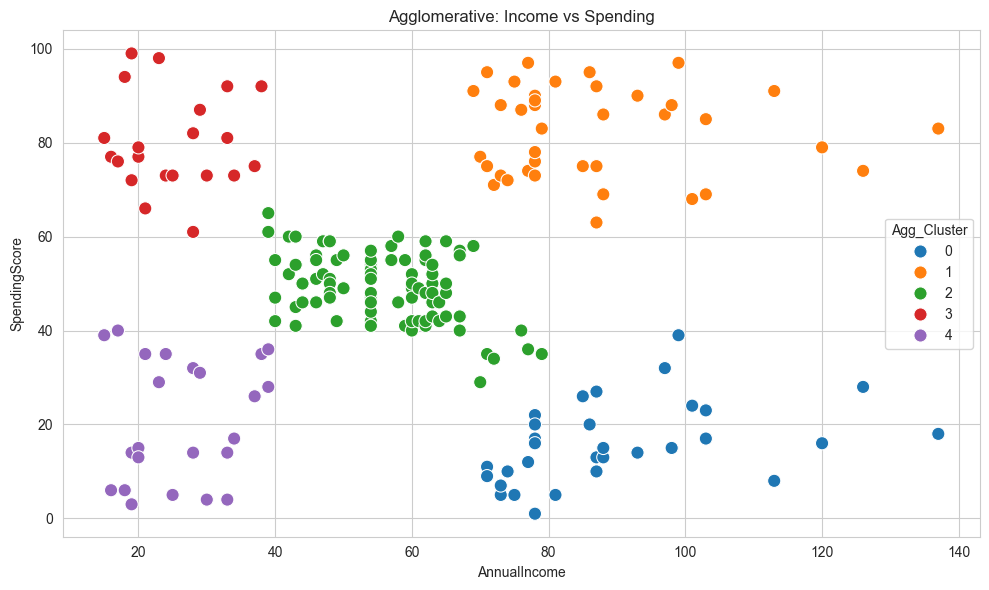

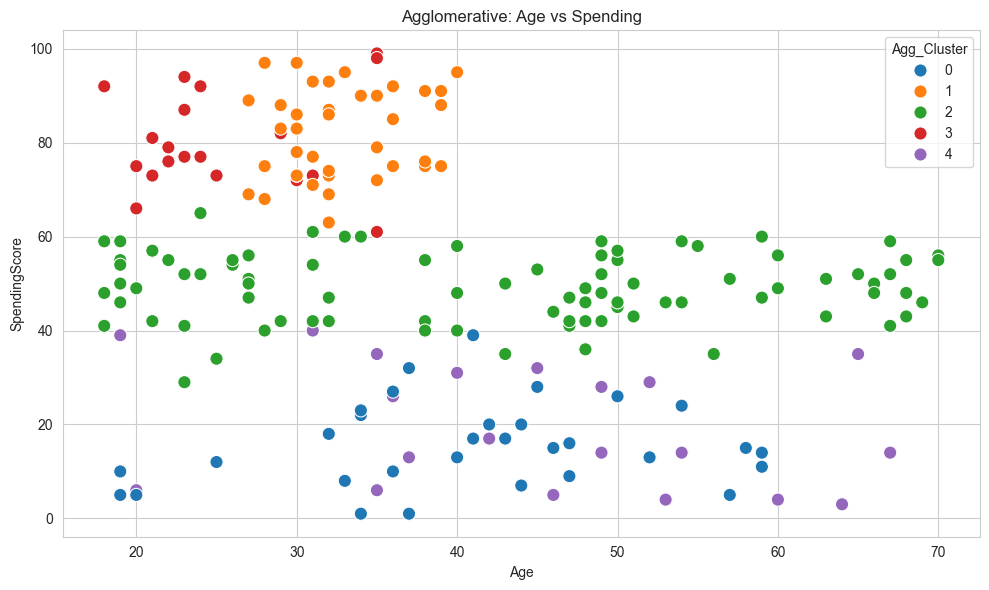

,Customers,Avg_Age,Avg_AnnualIncome,Avg_SpendingScore
Agg_Cluster,,,,
1,39,32.69,86.54,82.13
3,21,25.33,25.10,80.05
2,85,42.48,55.81,49.13
4,23,45.22,26.30,20.91
0,32,41.00,89.41,15.59


Direct label agreement: 31.5 %


In [140]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="AnnualIncome", y="SpendingScore",
                hue="Agg_Cluster", palette="tab10", s=90)
plt.title("Agglomerative: Income vs Spending")
plt.tight_layout()
plt.savefig("20_Agglomerative_Income_vs_Spending.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Age", y="SpendingScore",
                hue="Agg_Cluster", palette="tab10", s=90)
plt.title("Agglomerative: Age vs Spending")
plt.tight_layout()
plt.savefig("21_Agglomerative_Age_vs_Spending.png", dpi=300, bbox_inches="tight")
plt.show()

agg_profile = df.groupby("Agg_Cluster").agg(
    Customers=("CustomerID", "count"),
    Avg_Age=("Age", "mean"),
    Avg_AnnualIncome=("AnnualIncome", "mean"),
    Avg_SpendingScore=("SpendingScore", "mean")
).round(2).sort_values("Avg_SpendingScore", ascending=False)

display(agg_profile)

agreement = (df["KMeans_Cluster"] == df["Agg_Cluster"]).mean() * 100
print("Direct label agreement:", round(agreement, 2), "%")

# Task 5: DBSCAN Clustering

### Objective
Use 4-NN distance analysis, DBSCAN parameter tuning, noise analysis, visualization, and cluster profiling.

## Task 5.1: k-NN Distance Analysis

**Objective:** Use the 4th-nearest-neighbour distance curve to identify an initial epsilon.

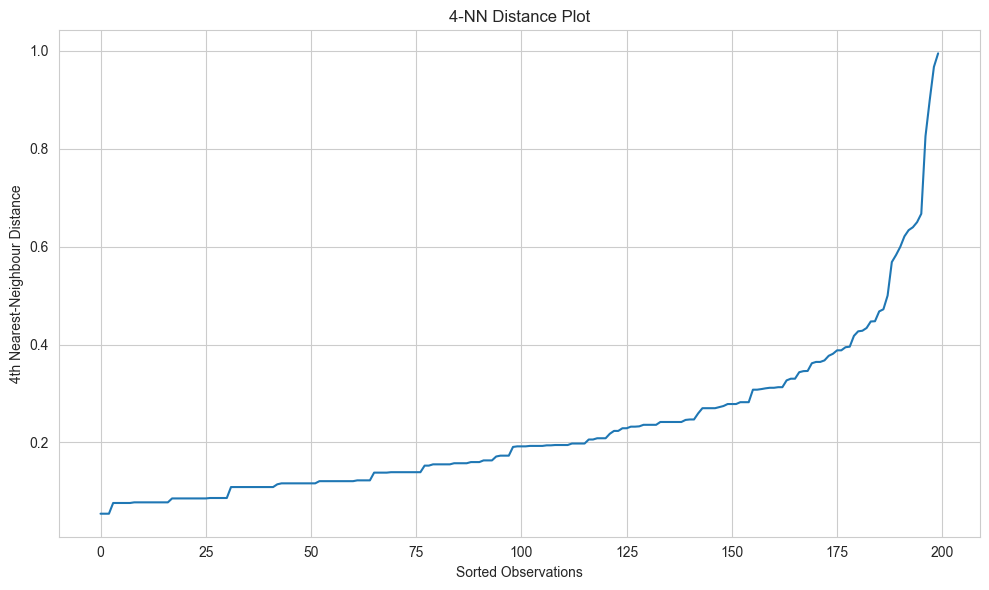

Initial epsilon: 0.4


In [141]:
neighbors = NearestNeighbors(n_neighbors=4)
neighbors.fit(X_2d_scaled)
distances, _ = neighbors.kneighbors(X_2d_scaled)
k_distance = np.sort(distances[:, 3])

plt.figure(figsize=(10, 6))
plt.plot(k_distance)
plt.xlabel("Sorted Observations")
plt.ylabel("4th Nearest-Neighbour Distance")
plt.title("4-NN Distance Plot")
plt.tight_layout()
plt.savefig("22_DBSCAN_4NN_Distance.png", dpi=300, bbox_inches="tight")
plt.show()

optimal_eps = 0.4
print("Initial epsilon:", optimal_eps)

## Task 5.2: Initial DBSCAN Model

**Objective:** Train DBSCAN with `eps=0.4` and `min_samples=4`, then report clusters and noise.

In [142]:
dbscan_initial = DBSCAN(eps=optimal_eps, min_samples=4, metric="euclidean")
initial_labels = dbscan_initial.fit_predict(X_2d_scaled)
df["DBSCAN_Initial_Cluster"] = initial_labels

initial_noise = (initial_labels == -1).sum()
initial_clusters = len(set(initial_labels)) - (1 if -1 in initial_labels else 0)

print("Clusters excluding noise:", initial_clusters)
print("Noise points:", initial_noise)
print("Noise percentage:", round(initial_noise / len(df) * 100, 2), "%")

Clusters excluding noise: 3
Noise points: 14
Noise percentage: 7.0 %


## Task 5.3: DBSCAN Grid Tuning

**Objective:** Test `eps=[0.2,0.4,0.6,0.8,1.0,1.2]` and `min_samples=[3,4,5,7,10]`. Only evaluate solutions with at least 2 clusters and less than 30% noise.

,eps,min_samples,clusters,noise_pct,silhouette
0,0.2,3,13,22.0,0.4697
1,0.2,4,5,36.5,NaN
2,0.2,5,7,38.5,NaN
3,0.2,7,4,50.0,NaN
4,0.2,10,1,64.5,NaN
5,0.4,3,4,5.0,0.3954
6,0.4,4,3,7.0,0.4576
7,0.4,5,4,7.5,0.4781
8,0.4,7,4,10.0,0.4946
9,0.4,10,4,25.5,0.5972


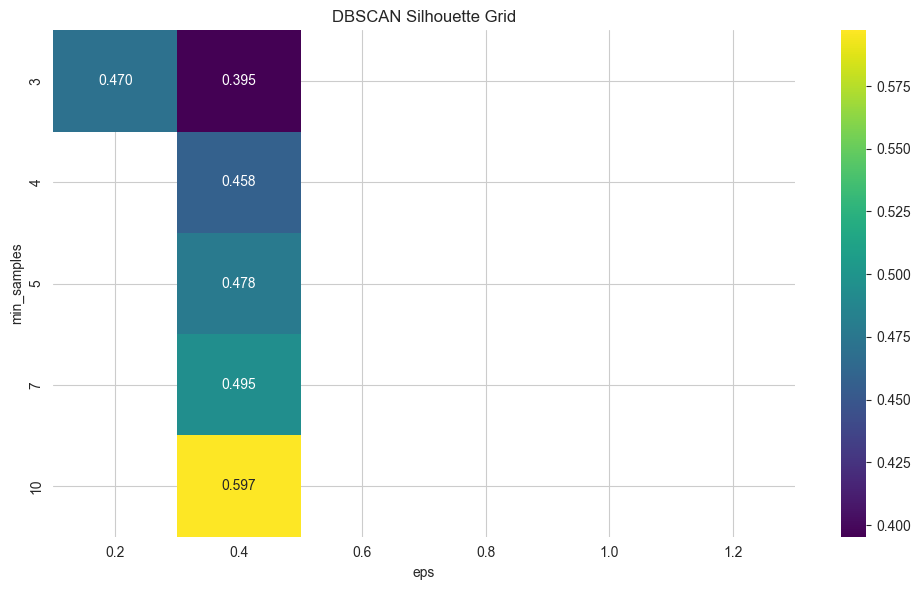

Best eps: 0.4
Best min_samples: 10


In [143]:
eps_values = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2]
min_samples_values = [3, 4, 5, 7, 10]
rows = []

for eps in eps_values:
    for ms in min_samples_values:
        model = DBSCAN(eps=eps, min_samples=ms, metric="euclidean")
        labels = model.fit_predict(X_2d_scaled)
        noise = labels == -1
        noise_pct = noise.mean() * 100
        clusters = len(set(labels)) - (1 if -1 in labels else 0)
        sil = np.nan

        if clusters >= 2 and noise_pct < 30:
            mask = ~noise
            if mask.sum() > clusters:
                sil = silhouette_score(X_2d_scaled[mask], labels[mask])

        rows.append({
            "eps": eps, "min_samples": ms, "clusters": clusters,
            "noise_pct": noise_pct, "silhouette": sil
        })

dbscan_results = pd.DataFrame(rows)
display(dbscan_results.round(4))

heat = dbscan_results.pivot(index="min_samples", columns="eps", values="silhouette")
plt.figure(figsize=(10, 6))
sns.heatmap(heat, annot=True, fmt=".3f", cmap="viridis")
plt.title("DBSCAN Silhouette Grid")
plt.tight_layout()
plt.savefig("23_DBSCAN_Grid_Heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

valid = dbscan_results.dropna(subset=["silhouette"])
if len(valid):
    best = valid.loc[valid["silhouette"].idxmax()]
    best_eps = float(best["eps"])
    best_min_samples = int(best["min_samples"])
else:
    best_eps, best_min_samples = 0.4, 4

print("Best eps:", best_eps)
print("Best min_samples:", best_min_samples)

## Task 5.4: Final DBSCAN Model

In [144]:
dbscan_model = DBSCAN(
    eps=best_eps, min_samples=best_min_samples, metric="euclidean"
)
df["DBSCAN_Cluster"] = dbscan_model.fit_predict(X_2d_scaled)

noise_mask = df["DBSCAN_Cluster"] == -1
n_clusters = df.loc[~noise_mask, "DBSCAN_Cluster"].nunique()
noise_count = int(noise_mask.sum())

print("Final clusters:", n_clusters)
print("Noise count:", noise_count)
print("Noise percentage:", round(noise_count / len(df) * 100, 2), "%")

Final clusters: 4
Noise count: 51
Noise percentage: 25.5 %


## Task 5.5: DBSCAN Visualization and Profiling

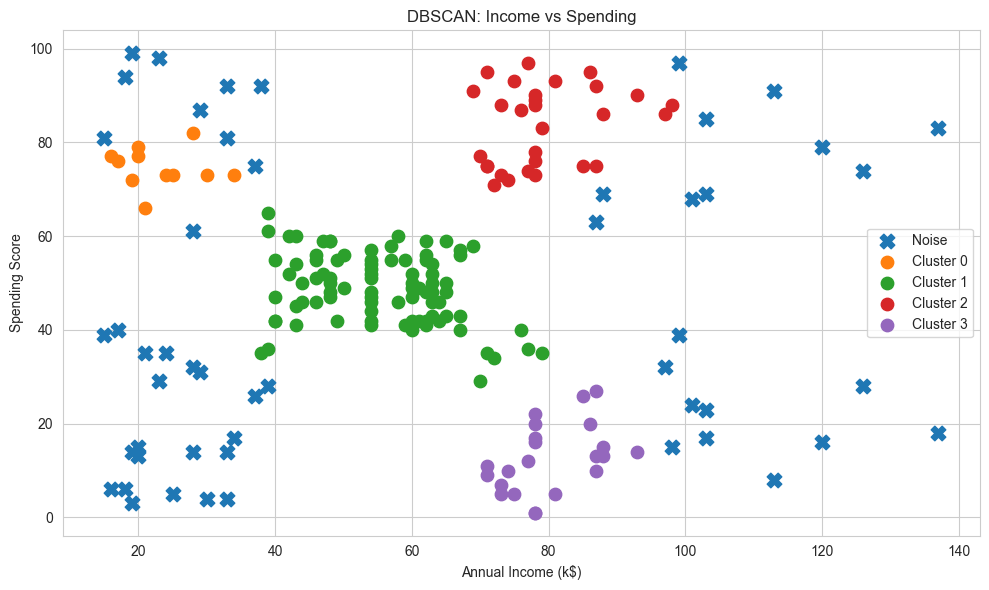

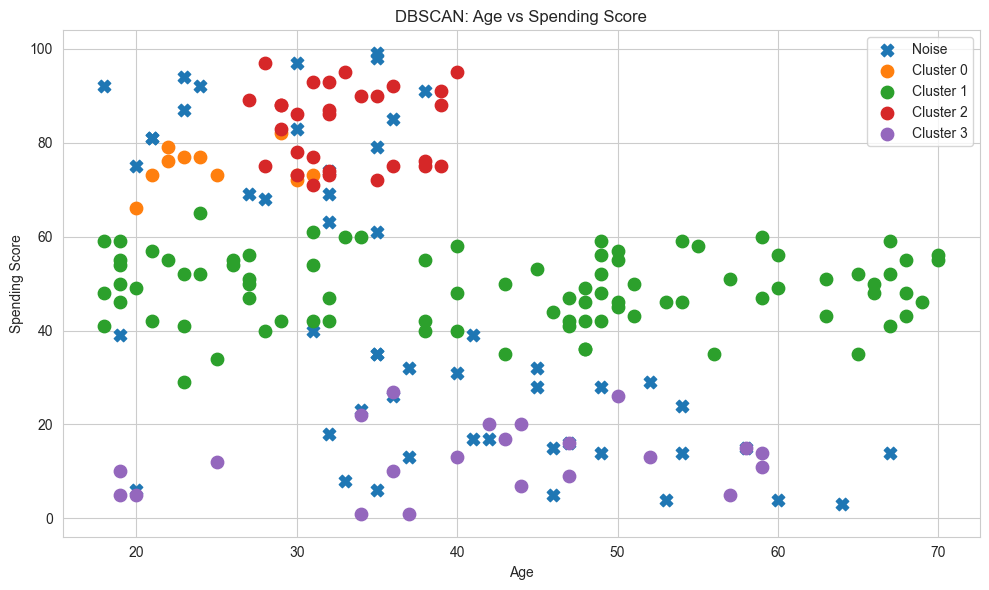

,Customers,Avg_Age,Avg_AnnualIncome,Avg_SpendingScore
DBSCAN_Cluster,,,,
2,29,32.93,79.24,83.62
0,11,25.18,23.09,74.64
1,87,42.80,55.41,48.82
3,22,41.00,80.18,12.68


Noise profile:


,Age,AnnualIncome,SpendingScore
count,51.00,51.00,51.00
mean,37.49,58.33,44.47
std,12.00,42.24,32.51
min,18.00,15.00,3.00
25%,30.50,23.00,15.50
50%,35.00,33.00,32.00
75%,45.50,101.00,77.00
max,67.00,137.00,99.00


In [145]:
plt.figure(figsize=(10, 6))
for cluster in sorted(df["DBSCAN_Cluster"].unique()):
    part = df[df["DBSCAN_Cluster"] == cluster]
    marker = "X" if cluster == -1 else "o"
    size = 110 if cluster == -1 else 80
    label = "Noise" if cluster == -1 else f"Cluster {cluster}"
    plt.scatter(part["AnnualIncome"], part["SpendingScore"],
                marker=marker, s=size, label=label)
plt.title("DBSCAN: Income vs Spending")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.legend()
plt.tight_layout()
plt.savefig("24_DBSCAN_Income_vs_Spending.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 6))
for cluster in sorted(df["DBSCAN_Cluster"].unique()):
    part = df[df["DBSCAN_Cluster"] == cluster]
    marker = "X" if cluster == -1 else "o"
    label = "Noise" if cluster == -1 else f"Cluster {cluster}"
    plt.scatter(part["Age"], part["SpendingScore"], marker=marker, s=80, label=label)
plt.title("DBSCAN: Age vs Spending Score")
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.legend()
plt.tight_layout()
plt.savefig("25_DBSCAN_Age_vs_Spending.png", dpi=300, bbox_inches="tight")
plt.show()

dbscan_profile = df[df["DBSCAN_Cluster"] != -1].groupby("DBSCAN_Cluster").agg(
    Customers=("CustomerID", "count"),
    Avg_Age=("Age", "mean"),
    Avg_AnnualIncome=("AnnualIncome", "mean"),
    Avg_SpendingScore=("SpendingScore", "mean")
).round(2)

display(dbscan_profile.sort_values("Avg_SpendingScore", ascending=False))

print("Noise profile:")
display(df[df["DBSCAN_Cluster"] == -1][
    ["Age", "AnnualIncome", "SpendingScore"]
].describe().round(2))

# Task 6: Model Comparison & Business Recommendations

### Objective
Compare all three algorithms using multiple metrics, test K-Means stability, and convert the segmentation into retail actions.

## Task 6.1: Multi-Metric Comparison

**Metric interpretation:**
- Silhouette: higher is better
- Davies-Bouldin: lower is better
- Calinski-Harabasz: higher is better
- Noise %: relevant to DBSCAN

In [146]:
def evaluate(X, labels):
    labels = np.asarray(labels)
    mask = labels != -1
    clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = (labels == -1).mean() * 100

    if clusters < 2 or mask.sum() <= clusters:
        return [clusters, np.nan, np.nan, np.nan, noise_pct]

    return [
        clusters,
        silhouette_score(X[mask], labels[mask]),
        davies_bouldin_score(X[mask], labels[mask]),
        calinski_harabasz_score(X[mask], labels[mask]),
        noise_pct
    ]

comparison = pd.DataFrame({
    "K-Means": evaluate(X_2d_scaled, df["KMeans_Cluster"].values),
    "Agglomerative": evaluate(X_2d_scaled, df["Agg_Cluster"].values),
    "DBSCAN": evaluate(X_2d_scaled, df["DBSCAN_Cluster"].values)
}, index=[
    "Clusters", "Silhouette", "Davies_Bouldin",
    "Calinski_Harabasz", "Noise_%"
]).T

display(comparison.round(4))

,Clusters,Silhouette,Davies_Bouldin,Calinski_Harabasz,Noise_%
K-Means,5.0,0.5547,0.5722,248.6493,0.0
Agglomerative,5.0,0.5538,0.5779,244.4103,0.0
DBSCAN,4.0,0.5972,0.4734,263.6118,25.5


### Task 6.1.1: Interpretation

Use all metrics together with the visualizations and business usefulness. Do not select an algorithm using only one metric.

## Task 6.2: K-Means Stability

**Objective:** Test seeds 0, 7, 21, 42, and 99 and calculate mean ± standard deviation of silhouette score.

In [147]:
seeds = [0, 7, 21, 42, 99]
stability = []

for seed in seeds:
    model = KMeans(
        n_clusters=k_optimal, init="k-means++",
        n_init=20, max_iter=500, random_state=seed
    )
    labels = model.fit_predict(X_2d_scaled)
    stability.append({
        "Seed": seed,
        "Silhouette": silhouette_score(X_2d_scaled, labels)
    })

stability_df = pd.DataFrame(stability)
display(stability_df.round(4))

mean_sil = stability_df["Silhouette"].mean()
std_sil = stability_df["Silhouette"].std()

print("Mean Silhouette:", round(mean_sil, 4))
print("Standard Deviation:", round(std_sil, 4))

,Seed,Silhouette
0,0,0.5547
1,7,0.5547
2,21,0.5547
3,42,0.5547
4,99,0.5547


Mean Silhouette: 0.5547
Standard Deviation: 0.0


### Stability Interpretation

A small standard deviation indicates that the selected K-Means solution is relatively stable across different random seeds. A larger value suggests sensitivity to initialization and should be investigated.

## Task 6.3: Business Segment Summary

**Objective:** Translate cluster profiles into actionable retail strategies.

Possible strategies include:
- High income + high spending → premium loyalty rewards
- High income + low spending → personalized conversion campaigns
- Low income + high spending → value bundles
- Low income + low spending → entry-level offers
- Medium income + medium spending → cross-selling and category recommendations

Match the strategy to the actual cluster profile rather than relying on cluster number.

In [148]:
business_profile = df.groupby("KMeans_Cluster").agg(
    Customers=("CustomerID", "count"),
    Avg_Age=("Age", "mean"),
    Avg_AnnualIncome=("AnnualIncome", "mean"),
    Avg_SpendingScore=("SpendingScore", "mean")
).round(2)

business_profile["Customer_%"] = (
    business_profile["Customers"] / len(df) * 100
).round(2)

display(business_profile.sort_values("Avg_SpendingScore", ascending=False))

,Customers,Avg_Age,Avg_AnnualIncome,Avg_SpendingScore,Customer_%
KMeans_Cluster,,,,,
1,39,32.69,86.54,82.13,19.5
2,22,25.27,25.73,79.36,11.0
0,81,42.72,55.30,49.52,40.5
4,23,45.22,26.30,20.91,11.5
3,35,41.11,88.20,17.11,17.5


## Task 6.4: Additional Data Recommendations

For a real retail deployment, useful additional variables could include purchase frequency, average transaction value, product category preference, visit frequency, promotion response, loyalty membership, recency, store/zone visited, digital engagement, and seasonal behaviour.

# Task 7: Deployment Preparation & GitHub Deliverables

### Objective
Save the scaler and final model, create a reusable shopper classification function, test hypothetical shoppers, and prepare repository artifacts.

## Task 7.1: Save Model and Scaler

In [149]:
joblib.dump(scaler_2d, "mall_scaler.pkl")
joblib.dump(kmeans_2d, "mall_segmentation_model.pkl")

print("Saved mall_scaler.pkl")
print("Saved mall_segmentation_model.pkl")

Saved mall_scaler.pkl
Saved mall_segmentation_model.pkl


## Task 7.2: Create Shopper Persona Mapping

The cluster number is arbitrary, so persona names are assigned from the observed average spending order and then should be reviewed against the full cluster profile.

In [150]:
ordered = df.groupby("KMeans_Cluster")["SpendingScore"].mean().sort_values().index.tolist()

persona_names = [
    "Budget Shoppers",
    "Careful Spenders",
    "Balanced Shoppers",
    "Young Aspirers",
    "Big Spenders"
]

persona_map = {
    cluster: persona_names[min(i, len(persona_names)-1)]
    for i, cluster in enumerate(ordered)
}

print(persona_map)

{3: 'Budget Shoppers', 4: 'Careful Spenders', 0: 'Balanced Shoppers', 2: 'Young Aspirers', 1: 'Big Spenders'}


## Task 7.3: Reusable Shopper Classification Function

**Objective:** Accept raw Age, Annual Income, Spending Score, and optional Gender and return a cluster and persona.

The deployed 2D model uses AnnualIncome and SpendingScore for prediction.

In [151]:
def classify_shopper(age, annual_income, spending_score, gender=None):
    new_customer = np.array([[annual_income, spending_score]])
    scaled_customer = scaler_2d.transform(new_customer)
    cluster = int(kmeans_2d.predict(scaled_customer)[0])

    return {
        "Age": age,
        "AnnualIncome": annual_income,
        "SpendingScore": spending_score,
        "Gender": gender,
        "Cluster": cluster,
        "Persona": persona_map.get(cluster, f"Cluster {cluster}")
    }

## Task 7.4: Test Five Hypothetical Shoppers

In [152]:
test_shoppers = [
    {"age": 22, "income": 30, "score": 85, "gender": "Female"},
    {"age": 35, "income": 75, "score": 70, "gender": "Male"},
    {"age": 45, "income": 25, "score": 30, "gender": "Female"},
    {"age": 28, "income": 60, "score": 50, "gender": "Male"},
    {"age": 55, "income": 90, "score": 20, "gender": "Female"}
]

predictions = pd.DataFrame([
    classify_shopper(
        x["age"], x["income"], x["score"], x["gender"]
    )
    for x in test_shoppers
])

display(predictions)

,Age,AnnualIncome,SpendingScore,Gender,Cluster,Persona
0,22,30,85,Female,2,Young Aspirers
1,35,75,70,Male,1,Big Spenders
2,45,25,30,Female,4,Careful Spenders
3,28,60,50,Male,0,Balanced Shoppers
4,55,90,20,Female,3,Budget Shoppers


# Final Deliverables Checklist

### Required notebook
`MallShopperSegmentation_UnsupervisedLearning.ipynb`

### Required model files
- `mall_scaler.pkl`
- `mall_segmentation_model.pkl`

### Recommended repository
`mall-shopper-segmentation-unsupervised-learning`

### Recommended files
```text
mall-shopper-segmentation-unsupervised-learning/
├── Mall_Customers.csv
├── MallShopperSegmentation_UnsupervisedLearning.ipynb
├── mall_scaler.pkl
├── mall_segmentation_model.pkl
├── summary_report.md
├── requirements.txt
└── README.md
```

### requirements.txt
```text
pandas
numpy
matplotlib
seaborn
scikit-learn
scipy
plotly
joblib
```

### Final validation
Restart the kernel, run all cells from top to bottom, confirm there are no errors, then save the executed notebook.